In [1]:
%load_ext autoreload
%autoreload 2

In [72]:
import h5py, os, tqdm
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '0.49'
import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp

from jax.experimental.ode import odeint

from jaxpm.painting import cic_paint, cic_read, compensate_cic
from jaxpm.utils import power_spectrum
from jaxpm.kernels import fftk, gradient_kernel, invlaplace_kernel, longrange_kernel, invnabla_kernel
from jaxpm.nn import MLP
from jaxpm import camels, hpm, pm

jax.devices("gpu")

[cuda(id=0)]

In [14]:
boxsize = 25.0 # Mpc/h
parts_per_dim = 64
mesh_per_dim = parts_per_dim
mesh_shape = [mesh_per_dim] * 3

## Loading the snapshots

In [75]:
# i_snapshots=range(1, 33+4, 4)
i_snapshots=[0,-1]
# i_snapshots=[-1]

In [76]:
SIM = "/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0"

nbody_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
    return_hydro=False
)

hydro_dict = camels.load_CV_snapshots(
    SIM,
    mesh_per_dim,
    parts_per_dim,
    i_snapshots=i_snapshots,
)

Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_014.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)


loading snapshots: 100%|██████████| 2/2 [00:08<00:00,  4.26s/it]


Using snapshots ['/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_014.hdf5', '/cluster/work/refregier/athomsen/flatiron/CAMELS/Sims/IllustrisTNG/CV/CV_0/snapshot_090.hdf5']
Selecting 262144 dark matter (deterministic)
Selecting 262144 gas particles (random)


loading snapshots: 100%|██████████| 2/2 [00:19<00:00,  9.57s/it]


In [77]:
def get_cls(field):
    kbins, cls = power_spectrum(
        compensate_cic(field),
        boxsize=np.array([boxsize] * 3),
        kmin=np.pi / boxsize,
        dk=2 * np.pi / boxsize,
    )

    return kbins, cls

In [90]:
def plot_cls(nbody_rho, hydro_rho):
    kbins, nbody_cls = get_cls(nbody_rho)
    kbins, hydro_cls = get_cls(hydro_rho)

    fig, ax = plt.subplots(figsize=(2*4, 6), nrows=2, sharex="col")
    
    ax[0].plot(kbins, nbody_cls, label="nbody")
    ax[0].plot(kbins, hydro_cls, label="hydro")
    
    ax[0].set(xscale="log", ylabel=r"$P(k)$")
    ax[0].legend()
    ax[0].grid(True)
    
    ax[1].plot(kbins, hydro_cls/nbody_cls-1, color="k")
    ax[1].set(xlabel=r"$k \; [h \, \text{Mpc}^{-1}]$", ylabel=r"$(P_\text{hydro}(k) / P_\text{nbody}(k)) - 1$")
    ax[1].grid(True)

    return fig, ax

# CAMELS

In [79]:
i = -1

nbody_rho_tot = cic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"][i])

hydro_rho_tot = cic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"][i], weight=1 - cosmo.Omega_b / cosmo.Omega_c)
hydro_rho_tot += cic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"][i], weight=cosmo.Omega_b / cosmo.Omega_c)

kbins, nbody_cls_tot = get_cls(nbody_rho_tot)
kbins, hydro_cls_tot = get_cls(hydro_rho_tot)

Text(0.5, 0.98, 'CAMELS')

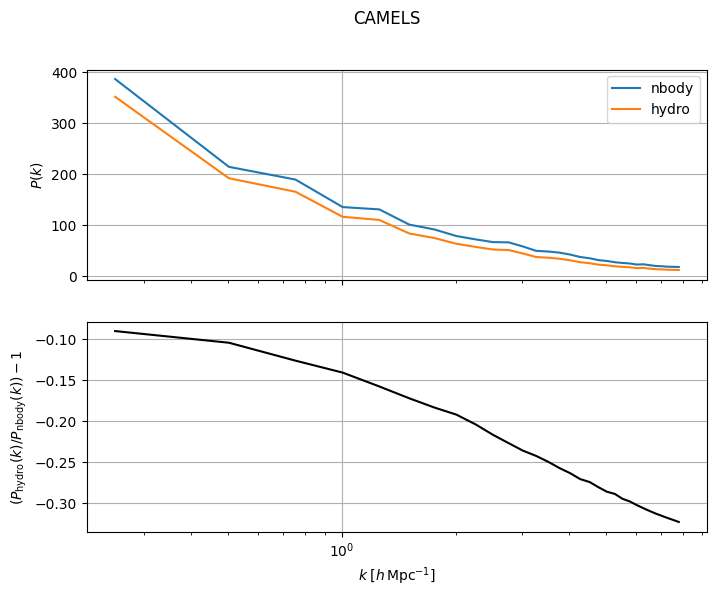

In [91]:
fig, ax = plot_cls(nbody_rho_tot, hydro_rho_tot)
fig.suptitle("CAMELS")

In [89]:
# fig, ax = plt.subplots(figsize=(2*4, 6), nrows=2, sharex="col")

# ax[0].plot(kbins, nbody_cls_tot, label="nbody")
# ax[0].plot(kbins, hydro_cls_tot, label="hydro")

# ax[0].set(xscale="log", ylabel=r"$P(k)$")
# ax[0].legend()
# ax[0].grid(True)

# ax[1].plot(kbins, hydro_cls_tot/nbody_cls_tot-1, color="k")
# ax[1].set(xlabel=r"$k \; [h \, \text{Mpc}^{-1}]$", ylabel=r"$(P_\text{hydro}(k) / P_\text{nbody}(k)) - 1$")
# ax[1].grid(True)

# fig.suptitle("CAMELS");

# Particle Mesh

In [86]:
pm_ode = pm.make_ode_fn(mesh_shape)
res = odeint(pm_ode, [nbody_dict["dm_poss"][0], nbody_dict["dm_vels"][0]], nbody_dict["scales"], cosmo, rtol=1e-5, atol=1e-5)

pm_dm_poss, pm_dm_vels = res[0], res[1]

In [96]:
pm_rho_tot = cic_paint(jnp.zeros(mesh_shape), pm_dm_poss[i])
kbins, pm_cls_tot = get_cls(pm_rho_tot)

In [ ]:
model = MLP(
    d_in=3, 
    d_out=1, 
    d_hidden=64, 
    n_hidden=4, 
    rngs=nnx.Rngs(0)
)

In [95]:
pm_rho_tot.shape

(64, 64, 64)

[None]

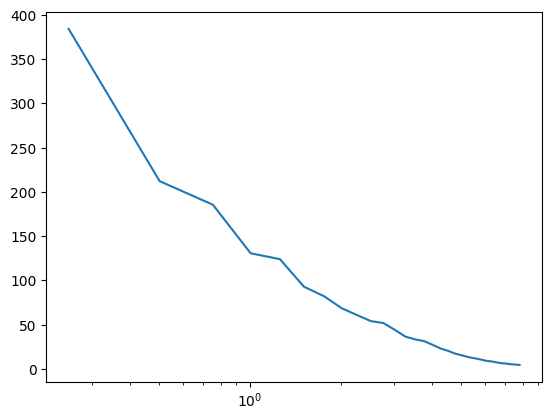

In [99]:
fig, ax = plt.subplots()

ax.plot(kbins, pm_cls_tot, label="nbody")
ax.set(xscale="log")


In [ ]:
fig, ax = plot_cls(nbody_rho_tot, hydro_rho_tot)
fig.suptitle("PM")

In [ ]:
fig, ax = plt.subplots(figsize=(2*4, 6), nrows=2, sharex="col")

ax[0].plot(kbins, nbody_cls_tot, label="nbody")
ax[0].plot(kbins, hydro_cls_tot, label="hydro")

ax[0].set(xscale="log", ylabel=r"$P(k)$")
ax[0].legend()
ax[0].grid(True)

ax[1].plot(kbins, hydro_cls_tot/nbody_cls_tot-1, color="k")
ax[1].set(xlabel=r"$k \; [h \, \text{Mpc}^{-1}]$", ylabel=r"$(P_\text{hydro}(k) / P_\text{nbody}(k)) - 1$")
ax[1].grid(True)

fig.suptitle("CAMELS");

In [70]:
pm_ode = hpm.get_hpm_network_ode_fn(None, mesh_shape, cosmo, "odeint", gravity_only=True)

# res = odeint(pm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {"gas_latent": jnp.ones(parts_per_dim**3)}, rtol=1e-5, atol=1e-5)
res = odeint(pm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {}, rtol=1e-5, atol=1e-5)
pm_dm_poss, pm_dm_vels, pm_gas_poss, pm_gas_vels = res[0], res[1], res[2], res[3]

NameError: name 'dm_poss' is not defined

In [33]:
# hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "odeint", architecture=architecture)
# # hpm_ode = hpm.get_hpm_network_ode_fn(model, mesh_shape, cosmo, "odeint", force_type="gnn", edges=edges)
# # hpm_ode = lambda state, scale: gnn_hpm_ode(scale, state, None)

# res = odeint(hpm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {"gas_latent": jnp.ones(parts_per_dim**3)}, rtol=1e-5, atol=1e-5, mxstep=20)
# # res = odeint(hpm_ode, [dm_poss[0], dm_vels[0], gas_poss[0], gas_vels[0]], scales, {}, rtol=1e-5, atol=1e-5, mxstep=20)
# hpm_dm_poss, hpm_dm_vels, hpm_gas_poss, hpm_gas_vels = res[0], res[1], res[2], res[3]

[None]

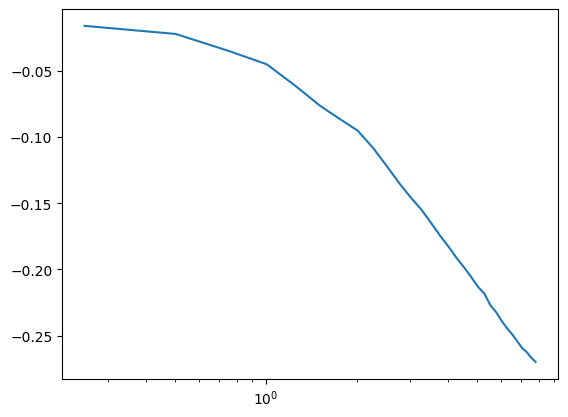

In [48]:
fig, ax = plt.subplots()

ax.plot(kbins, hydro_cls_tot/nbody_cls_tot-1)
ax.set(xscale="log")

In [45]:
kbins, nbody_cls_tot = get_cls(nbody_rho_tot)
kbins, hydro_cls_tot = get_cls(hydro_rho_tot)

In [33]:
cosmo = hydro_dict["cosmo"]

In [34]:
nbody_rho_tot = cic_paint(jnp.zeros(mesh_shape), nbody_dict["dm_poss"])

In [35]:
hydro_rho_tot = cic_paint(jnp.zeros(mesh_shape), hydro_dict["dm_poss"])
hydro_rho_tot += cic_paint(jnp.zeros(mesh_shape), hydro_dict["gas_poss"], weight=cosmo.Omega_b / cosmo.Omega_c)

In [41]:
jnp.sum(nbody_rho_tot)

Array(262144., dtype=float32)

In [42]:
jnp.sum(hydro_rho_tot)

Array(262144., dtype=float32)

In [24]:
kbins, nbody_cls_tot = get_total_matter_spectrum(nbody_dict)
kbins, hydro_cls_tot = get_total_matter_spectrum(hydro_dict)

In [ ]:
dm_pos = dm_dict["dm_poss"]
gas_pos = dm_dict["gas_poss"]

In [ ]:
rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)
rho_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=cosmo.Omega_b / cosmo.Omega_c)
rho_tot = rho_dm + rho_gas


In [ ]:
# per-particle reference
ref_pos = jnp.stack(gas_poss, axis=0)
ref_vel = jnp.stack(gas_vels, axis=0)

# field-level reference
ref_rho = vcic_paint(jnp.zeros(mesh_shape), gas_poss, cosmo.Omega_b / cosmo.Omega_c)

    res_rho = vcic_paint(jnp.zeros(mesh_shape), res[2], cosmo.Omega_b / cosmo.Omega_c)
    _, res_cls = vpower_spectrum(res_rho)
    cl_loss = jnp.mean(jnp.sum((res_cls/ref_cls - 1)**2, axis=-1))


In [78]:
# def get_total_matter_spectrum(snapshot_dict):
#     cosmo = snapshot_dict["cosmo"]
    
#     dm_pos = snapshot_dict["dm_poss"]
#     rho_dm = cic_paint(jnp.zeros(mesh_shape), dm_pos)

#     try:
#         gas_pos = snapshot_dict["gas_poss"]
#         rho_gas = cic_paint(jnp.zeros(mesh_shape), gas_pos, weight=cosmo.Omega_b / cosmo.Omega_c)
#         rho_tot = rho_dm + rho_gas
#     except KeyError:
#         rho_tot = rho_dm

#     kbins, cls_tot = power_spectrum(
#         compensate_cic(rho_tot),
#         boxsize=np.array([boxsize] * 3),
#         kmin=np.pi / boxsize,
#         dk=2 * np.pi / boxsize,
#     )

#     return kbins, cls_tot